# Simple linear regression with no tuning

In [421]:
import numpy as np
import pandas as pd
import sys

from pathlib import Path
from sklearn.linear_model import LogisticRegression

# Own functions
# Necessary to import from src dir
sys.path.append("..")
import src.kaggle_helpers as kh
import src.preprocessing_minimal as ppm

## Reading in the data

In [422]:
from sklearn.model_selection import train_test_split

data_dir = Path('data')
output_dir = Path('outputs')

train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
final_test_df = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date"])
#final_test_df = final_test_df.drop(columns=[col for col in final_test_df.columns if col.endswith('.std')])

#train_df, test_df = train_test_split(train_df, test_size=0.3, random_state=42)

#train_df = ppm.generate_synthetic_data(train_df, num_datasets=100)

## Splitting to x and y variables

In [423]:
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
#X_test, y_test2, y_test4 = ppm.split_xy(test_df)
#X_test = X_test.drop(columns=[col for col in X_test.columns if col.endswith('.std')])

## Scaling data

In [424]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

## PCA step (not used rn)

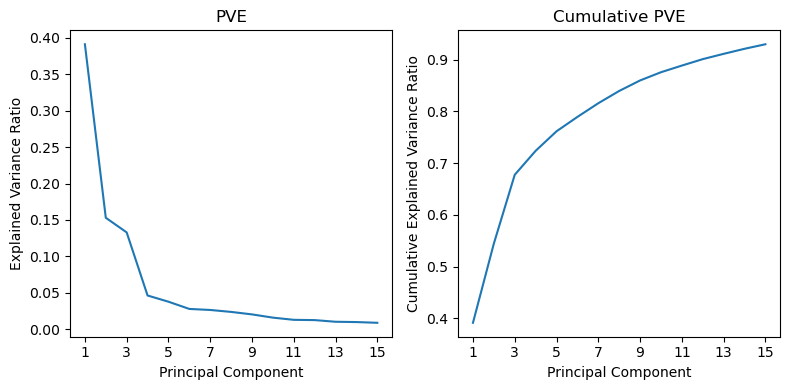

In [425]:
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_train_scaled)

#Plot the variance explained by each component
explained_variance = pca.explained_variance_ratio_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
p = sns.lineplot(x=range(1, len(explained_variance)+1), y=explained_variance, ax=ax1)
#Forcing integer x-axis labels
p.set_xticks(range(1, len(explained_variance)+1,2))
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('PVE')

p = sns.lineplot(x=range(1, len(explained_variance)+1), y=np.cumsum(explained_variance), ax=ax2)
p.set_xticks(range(1, len(explained_variance)+1,2))
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
ax2.set_title('Cumulative PVE')
plt.tight_layout()

plt.show()

In [426]:
#X_train_scaled = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])], index=X_train_scaled.index)

## Constructing event-nonevent classifier

In [427]:
#Fitting logistic regression to class2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


avg_accuracies = []
avg_perplexities = []

for c in np.linspace(0.1, 1.0, 20):
    accuracies = []
    perplexities = []
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    for train_index, test_index in skf.split(X_train_scaled, y_train2):
        X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
        y_train_fold, y_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
        log_model.fit(X_train_fold, y_train_fold)
        
        y_pred_fold = log_model.predict(X_test_fold)
        y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]

        binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
        perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
        accuracies.append(binary_accuracy)
        perplexities.append(perplexity)
    avg_accuracies.append(np.mean(accuracies))
    avg_perplexities.append(np.mean(perplexities))



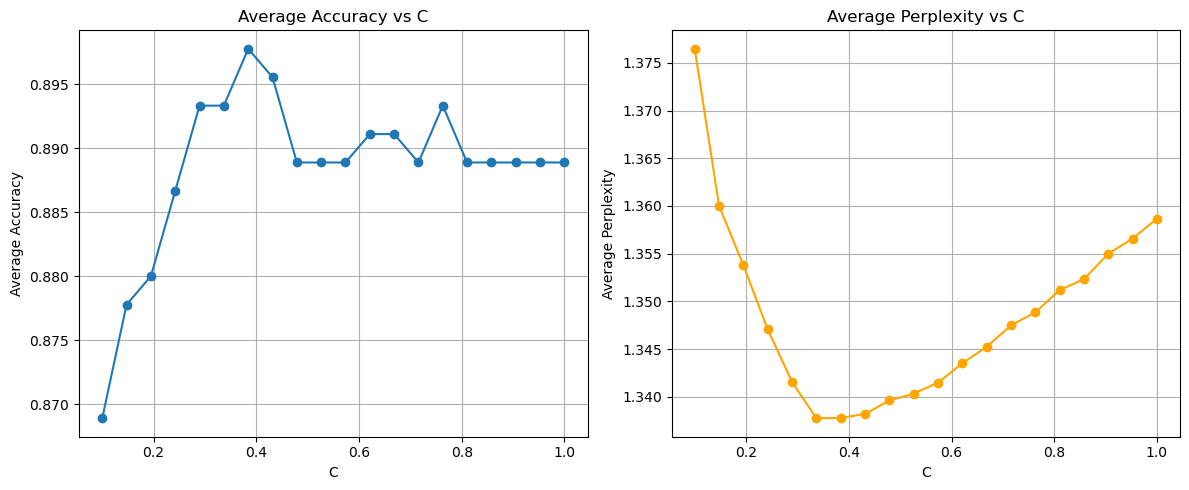

In [428]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.1, 1.0, 20), avg_accuracies, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.1, 1.0, 20), avg_perplexities, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

In [429]:
# Trainig the best model on the whole training set
best_c_index = np.argmax(avg_accuracies)
best_c = np.linspace(0.1, 1.0, 20)[best_c_index]
print(f"Best C: {best_c:.4f} with Average Accuracy: {avg_accuracies[best_c_index]:.4f} and Average Perplexity: {avg_perplexities[best_c_index]:.4f}")

best_log_model = LogisticRegression(C=best_c, l1_ratio=1, solver='liblinear')
best_log_model.fit(X_train_scaled, y_train2)


Best C: 0.3842 with Average Accuracy: 0.8978 and Average Perplexity: 1.3378


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0....1052631578945)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of 

## Testing different class4 classification methods

In [430]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


multi_accuracies = []
rf_model = RandomForestClassifier(n_estimators=160, random_state=42, n_jobs=-1)
for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    rf_model.fit(X_train_fold, y_train_fold)
    
    y_pred_fold = rf_model.predict(X_test_fold)

    multiclass_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    multi_accuracies.append(multiclass_accuracy)

print(f"Average Accuracy: {np.mean(multi_accuracies):.4f}")


Average Accuracy: 0.6689


In [431]:
best_rf_model = RandomForestClassifier(n_estimators=160, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train_scaled, y_train4)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",160
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Calculating a estimated Kaggle score

In [432]:
smallest_perplexity = np.min(avg_perplexities)

print(f"Binary accuracy: {avg_accuracies[best_c_index]:.4f}")
print(f"Multiclass accuracy: {np.mean(multi_accuracies):.4f}")
print(f"Perplexity: {smallest_perplexity:.4f}")

est_kaggle_score = 1/3 * (np.max(avg_accuracies) + np.mean(multi_accuracies) + np.max([0.0, np.min([1.0, 2.0 - smallest_perplexity])]) )
print(f'Estimated Kaggle Score: {est_kaggle_score:.4f}')

Binary accuracy: 0.8978
Multiclass accuracy: 0.6689
Perplexity: 1.3377
Estimated Kaggle Score: 0.7430


### Forming the output df

In [433]:
out_df = kh.generate_kaggle_output(
    final_test_df,
    model_prob=best_log_model,
    model_class4=best_rf_model,
    scaler=scaler
)
out_df.to_csv(output_dir / 'not_good_submission.csv', index=False)
out_df.head(10)

,id,class4,p
0,450,nonevent,0.720863
1,451,II,0.933067
2,452,nonevent,0.009992
3,453,nonevent,0.350498
4,454,Ib,0.883183
5,455,nonevent,0.054720
6,456,II,0.939353
7,457,Ib,0.976341
8,458,nonevent,0.310973
9,459,nonevent,0.213479
